---
date: "2026-07-28"
date-modified: last-modified
format:
  html:
    toc: true
---


# Conditional Heteroscedasticity (ARCH/GARCH)

## 1\. Characteristics of Financial Volatility

When analyzing financial time series, the variance (volatility) of the series, denoted by $\sigma$, is often not constant over time. If we treat the sample standard deviation as constant, we miss critical dynamics of the market. Empirical volatility exhibits three well-known properties:

1. **Volatility Clusters:** Large price changes tend to be followed by large price changes (of either sign), and small price changes tend to be followed by small price changes.
2. **It Changes Slowly:** Volatility does not jump erratically; it evolves over time in a continuous manner.
3. **Leverage Effect:** Volatility tends to respond asymmetrically to price changes. A large price drop (bad news) typically increases volatility more than a large price increase (good news) of the same magnitude.

## 2\. Conditional vs Unconditional Variance

Recall the general decomposition of a [return](time-series-returns.ipynb) series:
$$
r_t = \mu_t + a_t
$$
where $\mu_t$ is the conditional mean (modeled by [ARMA](arma-models.ipynb) or Exogenous variables) and $a_t$ is the shock.

::: {#def-homoscedasticity}
## Homoscedasticity
If the conditional variance is constant over time:
$$
\text{Var}[r_t | F_{t-1}] = \text{Var}(a_t) = \sigma^2
$$
where $F_{t-1}$ is the information set available at time $t-1$. We say the model is conditionally homoscedastic.
:::

Because financial returns have volatility clusters, the constant variance assumption is flawed.

::: {#def-ch-model}
## Conditional Heteroscedasticity (CH)
We model the variance itself as a time-varying process depending on the information set:
$$
\sigma_t^2 = \text{Var}[r_t | F_{t-1}]
$$
This leads to the class of Conditional Heteroscedastic (CH) models.
:::

## 3\. ARCH(m) Model

The simplest CH model is the Autoregressive Conditional Heteroscedasticity (ARCH) model, which assumes that the current volatility is a linear function of the past squared shocks.

::: {#def-arch-m}
## ARCH(m) Model
The shock $a_t$ is defined as:
$$
a_t = \sigma_t \epsilon_t
$$
where $\epsilon_t \sim \text{iid}(0,1)$ (usually a standard normal or Student-t distribution), and the conditional variance $\sigma_t^2$ evolves as an AR(m) process on squared shocks:
$$
\sigma_t^2 = \alpha_0 + \alpha_1 a_{t-1}^2 + \alpha_2 a_{t-2}^2 + \dots + \alpha_m a_{t-m}^2
$$
with $\alpha_0 > 0$ and $\alpha_i \ge 0$ for $i > 0$ to ensure the variance is strictly positive.
:::

## 4\. GARCH(m,s) Model

The ARCH model often requires a very large $m$ to fit financial data properly. To create a more parsimonious model, the Generalized ARCH (GARCH) model introduces past variances into the equation, similar to how an ARMA model extends an AR model.

::: {#def-garch-ms}
## GARCH(m,s) Model
The conditional variance $\sigma_t^2$ depends on both past squared shocks and past conditional variances:
$$
\sigma_t^2 = \alpha_0 + \sum_{i=1}^m \alpha_i a_{t-i}^2 + \sum_{j=1}^s \beta_j \sigma_{t-j}^2
$$
For a GARCH(1,1) model (the most common in practice):
$$
\sigma_t^2 = \alpha_0 + \alpha_1 a_{t-1}^2 + \beta_1 \sigma_{t-1}^2
$$
To ensure a positive and stationary variance, we require $\alpha_0 > 0$, $\alpha_1 \ge 0$, $\beta_1 \ge 0$, and $\alpha_1 + \beta_1 < 1$.
:::

## 5\. General Framework of Time Series Modeling

The complete procedure for modeling a financial time series often involves two distinct parts:

1. **Mean Equation:** Use ARMA or regression to model the conditional mean $\mu_t = E[r_t | F_{t-1}]$.
2. **Volatility Equation:** Use a CH model (ARCH/GARCH) to model the conditional variance $\sigma_t^2 = \text{Var}[a_t | F_{t-1}]$.


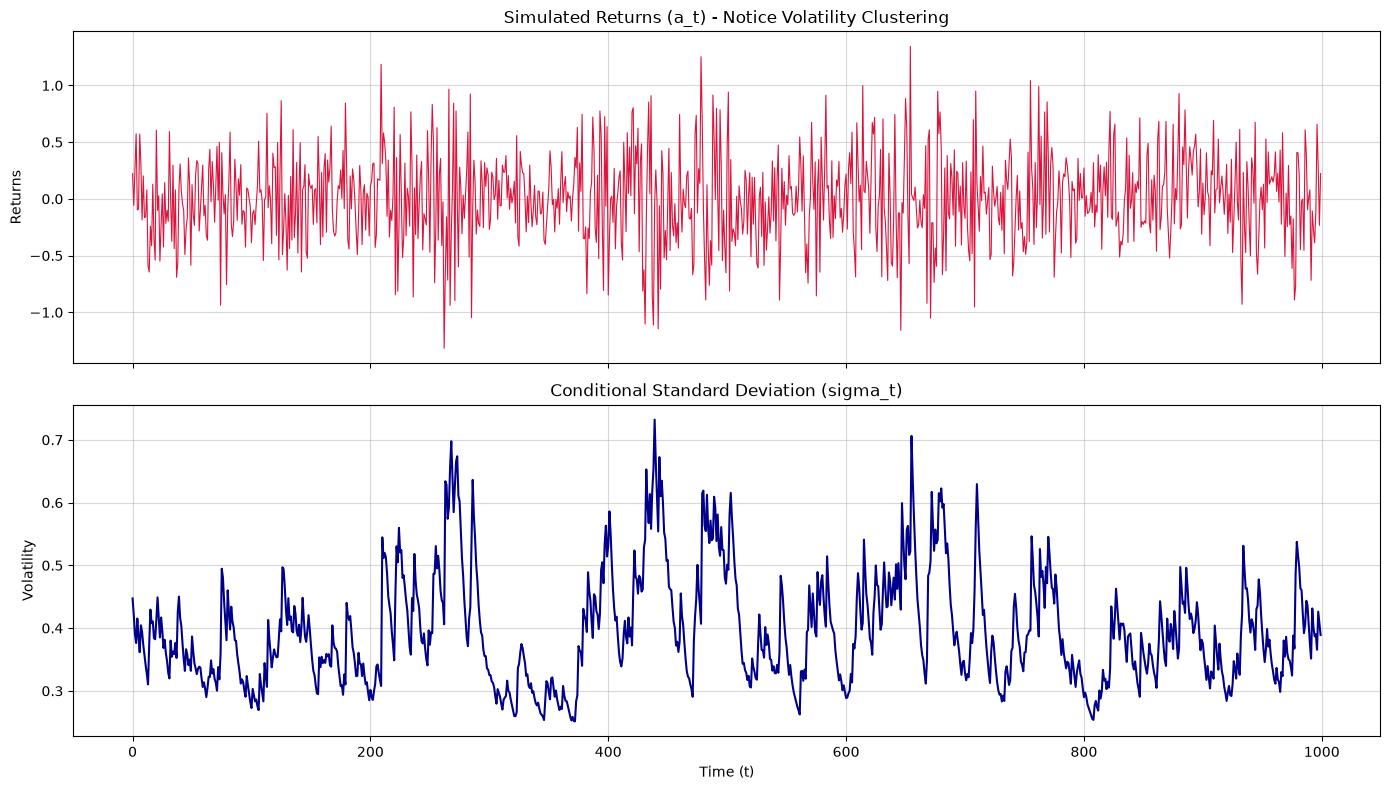

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulate GARCH(1,1) Process manually
# sigma_t^2 = alpha_0 + alpha_1 * a_{t-1}^2 + beta_1 * sigma_{t-1}^2
# a_t = sigma_t * epsilon_t

T = 1000
alpha_0 = 0.01
alpha_1 = 0.15
beta_1 = 0.8  # Note: alpha_1 + beta_1 = 0.95 < 1 (Stationary)

epsilon = np.random.normal(0, 1, T)
sigma2 = np.zeros(T)
a_t = np.zeros(T)

# Initialize
sigma2[0] = alpha_0 / (1 - alpha_1 - beta_1) # Unconditional variance
a_t[0] = np.sqrt(sigma2[0]) * epsilon[0]

for t in range(1, T):
    sigma2[t] = alpha_0 + alpha_1 * (a_t[t-1]**2) + beta_1 * sigma2[t-1]
    a_t[t] = np.sqrt(sigma2[t]) * epsilon[t]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(a_t, color='crimson', linewidth=0.8)
axes[0].set_title("Simulated Returns (a_t) - Notice Volatility Clustering")
axes[0].set_ylabel("Returns")
axes[0].grid(True, alpha=0.5)

axes[1].plot(np.sqrt(sigma2), color='darkblue', linewidth=1.5)
axes[1].set_title("Conditional Standard Deviation (sigma_t)")
axes[1].set_xlabel("Time (t)")
axes[1].set_ylabel("Volatility")
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


> **References & Acknowledgments:**
> Notes adapted from *Analysis of Financial Time Series*, 2nd/3rd Edition by Ruey S. Tsay.